In [55]:
import numpy as np
import pandas as pd

In [10]:
splits = pd.read_json('../data/dbptm/splits_S_chunked_max.json')
prot_info = pd.read_json('../data/dbptm/dbptm_info_chunked.json')

In [11]:
prot_info.iloc[splits['test'][0]]['id']

3          A0A023PZG4
5        A0A061ACU2_0
6        A0A061ACU2_1
7        A0A061ACU2_2
41       A0A087WUL8_0
             ...     
69296          Q9Y6H3
69322          Q9Y7R3
69330          Q9Y7V1
69336          Q9Y7Z4
69436          Q9ZPQ8
Name: id, Length: 2277, dtype: object

In [13]:
source_folder = '../data/embeddings/finetuning_drop_S_2_650M_dbptm_chunked_max'
embed=np.load(f'{source_folder}/Q9Y7B3.npz')

In [18]:
list(embed.keys())

['embeddings',
 'positions',
 'sequence',
 'id',
 'chunk_offsets',
 'chunk_ids',
 'chunk_0',
 'chunk_positions_0',
 'chunk_1',
 'chunk_positions_1',
 'chunk_2',
 'chunk_positions_2',
 'attention_layers',
 'attention_0',
 'attention_positions_0',
 'attention_special_0',
 'attention_1',
 'attention_positions_1',
 'attention_special_1',
 'attention_2',
 'attention_positions_2',
 'attention_special_2']

In [21]:
embed['attention_0'].shape

(3, 20, 101, 1022)

In [ ]:
embed['attention_0'][:, :, 0, :]

array([[0.9204, 0.2037, 0.774 , 0.6665, 0.9883, 0.9727, 0.4207, 0.9795,
        0.9297, 0.9414, 0.8047, 0.999 , 0.762 , 0.7383, 0.7397, 0.4287,
        0.8525, 0.4258, 0.996 , 0.9673],
       [0.508 , 0.831 , 0.9814, 1.    , 0.984 , 0.9985, 0.689 , 0.9873,
        0.4255, 0.2228, 0.9517, 0.783 , 0.0886, 0.968 , 1.    , 0.9995,
        0.462 , 0.7466, 0.696 , 0.9136],
       [0.9546, 0.879 , 0.93  , 0.785 , 0.96  , 0.9688, 0.9077, 0.9424,
        0.727 , 0.718 , 0.819 , 0.641 , 0.6904, 0.9355, 1.    , 0.395 ,
        0.7046, 0.9507, 0.985 , 0.9995]], dtype=float16)

## Attention scores: the distribution across the heads, and its entropy

`model/compute_embeddings.py --attention_layers` writes, per chunk of a protein, the attention of
the saved layers as `attention_<c>` of shape `(layers, heads, query residues, keys)`. Two things
about that layout matter here:

- the query rows are only the residues the run selected (`--residues`), in whole protein
  coordinates in `attention_positions_<c>`, while the key columns are **every** position of the
  chunk, column `j` being whole protein position `j + chunk_offsets[c]`;
- the `[CLS]` and `[EOS]` columns are kept apart, in `attention_special_<c>`, so neither array on
  its own is a distribution. `load_chunk_attention` puts them back in token order, `[CLS]` first
  and `[EOS]` last, and from there on every row sums to one and the special tokens are ordinary
  keys in every plot and every number below.

Entropies are in bits. A row over `k` keys can reach `log2(k)`, which is what a head attending to
the whole chunk equally would score, so `norm_entropy` (the entropy over that ceiling) is the
column to compare chunks of different length by, and `eff_keys` = `2 ** entropy` reads as "this
head spreads over about that many keys".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from glob import glob
from matplotlib.colors import LogNorm
from scipy.stats import entropy as shannon_entropy

import os

CLS, EOS = '[CLS]', '[EOS]'

In [2]:
@dataclass
class ChunkAttention:
    """
    The attention of one chunk, with the special tokens back where the model had them.

    "weights" is (layers, heads, queries, keys); a query row is one saved residue, a key column one
    token the chunk could attend to, [CLS] first and [EOS] last, so a row sums to one.
    """
    protein : str
    chunk : int
    chunk_id : str
    offset : int
    sequence : str          # Residues of this chunk, without the special tokens
    layers : np.ndarray     # Backbone layer index of each entry of the layer axis
    queries : np.ndarray    # Whole protein positions of the query residues
    keys : np.ndarray       # Key labels, [CLS] / residue letter / [EOS]
    key_pos : np.ndarray    # Whole protein position of each key, -1 for the two special tokens
    weights : np.ndarray

    @property
    def n_layers(self):
        return self.weights.shape[0]

    @property
    def n_heads(self):
        return self.weights.shape[1]

    @property
    def n_keys(self):
        return self.weights.shape[3]

    def layer_axis(self, layer : int):
        """Index into the layer axis of a backbone layer number, which is what the plots take."""
        return int(np.flatnonzero(self.layers == layer)[0])

    def query_labels(self):
        """Residue and 1 based whole protein position of every query row, e.g. "S184"."""
        return [f'{self.sequence[pos - self.offset]}{pos + 1}' for pos in self.queries]

    def self_columns(self):
        """Key column a query attends to itself through, the [CLS] column shifting it by one."""
        return self.queries - self.offset + 1

def n_chunks(embed):
    return len(embed['chunk_offsets'])

def load_chunk_attention(embed, chunk=0, renormalize=True):
    """
    Reads one chunk out of a file written by model/compute_embeddings.py --attention_layers.

    The residue columns ("attention_<c>") and the two special token columns
    ("attention_special_<c>") are stored apart, so neither is a distribution on its own; this puts
    them back together in token order. The rows land a few 1e-4 off one, which is the float16 the
    weights are saved as, and "renormalize" divides that out so they are distributions again.
    """
    residue = embed[f'attention_{chunk}'].astype(np.float32)
    special = embed[f'attention_special_{chunk}'].astype(np.float32)
    offset = int(embed['chunk_offsets'][chunk])
    sequence = str(embed['sequence'])[offset:offset + residue.shape[-1]]

    weights = np.concatenate([special[..., :1], residue, special[..., 1:]], axis=-1)
    if renormalize:
        weights /= weights.sum(axis=-1, keepdims=True)

    return ChunkAttention(
        protein=str(embed['id']),
        chunk=chunk,
        chunk_id=str(embed['chunk_ids'][chunk]),
        offset=offset,
        sequence=sequence,
        layers=np.asarray(embed['attention_layers']),
        queries=np.asarray(embed[f'attention_positions_{chunk}']),
        keys=np.array([CLS] + list(sequence) + [EOS]),
        key_pos=np.concatenate([[-1], np.arange(len(sequence)) + offset, [-1]]),
        weights=weights,
    )

### Entropy

Per head, the entropy is computed for every query row separately and then averaged, which is not
the same as the entropy of the head's average row (`mixture_bits`): the gap between the two is the
Jensen Shannon divergence of the rows, zero when the head attends the same way wherever it sits.
The same gap taken across the heads of a layer (`head_divergence`) says how differently the heads
of that layer look at the same residue, with `log2(heads)` as the ceiling.

In [3]:
def entropy(p, axis=-1):
    """
    Shannon entropy in bits along "axis": scipy's, with the base and the axis pinned to the ones
    the rest of the notebook works in. It normalizes the values to a distribution before taking the
    entropy and reads 0 log 0 as 0, so a row that float16 rounding left a fraction off one is fine.
    """
    return shannon_entropy(p, base=2, axis=axis)

def uniform_entropy(n_keys):
    """Entropy of attending to every key equally, the ceiling the rest is measured against."""
    return np.log2(n_keys)

def effective_keys(bits):
    """Perplexity: the number of keys a row would spread over if it spread over them evenly."""
    return 2.0 ** bits

def mean_concentration(att : ChunkAttention):
    """
    The keys of every query row sorted from the largest weight down and accumulated, averaged over
    the rows: entry [layer, head, k] is the share of the attention the k + 1 strongest keys hold.
    """
    ordered = np.sort(att.weights, axis=-1)[..., ::-1]
    return ordered.cumsum(axis=-1).mean(axis=2)

def keys_for_share(curve, share):
    """How many of the strongest keys a row needs to cover "share" of its attention."""
    return (curve < share).sum(axis=-1) + 1

In [4]:
def head_entropy_table(att : ChunkAttention):
    """
    One row per (layer, head): how spread out that head's attention is, and where its mass sits.

    "mean_bits" averages the entropies of the individual query rows, "mixture_bits" is the entropy
    of the head's average row, and "query_divergence" is the gap between them. "cls_mass",
    "eos_mass" and "self_mass" are the shares of the row the two special tokens and the query
    residue itself take, "top1_mass" the share of the single largest key.
    """
    per_row = entropy(att.weights)
    mixture = entropy(att.weights.mean(axis=2))
    curve = mean_concentration(att)
    queries = np.arange(len(att.queries))
    self_mass = att.weights[:, :, queries, att.self_columns()].mean(axis=-1)

    return pd.DataFrame({
        'layer' : np.repeat(att.layers, att.n_heads),
        'head' : np.tile(np.arange(att.n_heads), att.n_layers),
        'mean_bits' : per_row.mean(axis=-1).ravel(),
        'std_bits' : per_row.std(axis=-1).ravel(),
        'min_bits' : per_row.min(axis=-1).ravel(),
        'max_bits' : per_row.max(axis=-1).ravel(),
        'norm_entropy' : (per_row.mean(axis=-1) / uniform_entropy(att.n_keys)).ravel(),
        'eff_keys' : effective_keys(per_row.mean(axis=-1)).ravel(),
        'keys_50' : keys_for_share(curve, 0.5).ravel(),
        'keys_90' : keys_for_share(curve, 0.9).ravel(),
        'mixture_bits' : mixture.ravel(),
        'query_divergence' : (mixture - per_row.mean(axis=-1)).ravel(),
        'cls_mass' : att.weights[..., 0].mean(axis=-1).ravel(),
        'eos_mass' : att.weights[..., -1].mean(axis=-1).ravel(),
        'self_mass' : self_mass.ravel(),
        'top1_mass' : att.weights.max(axis=-1).mean(axis=-1).ravel(),
    })

def row_entropy_table(att : ChunkAttention):
    """
    The long form of the same entropies, one row per (layer, head, query residue), for grouping and
    plotting further: which residues of this chunk a head looks around from, and which it does not.
    """
    per_row = entropy(att.weights)
    layers, heads, queries = [axis.ravel() for axis in np.indices(per_row.shape)]

    return pd.DataFrame({
        'protein' : att.protein,
        'chunk_id' : att.chunk_id,
        'layer' : att.layers[layers],
        'head' : heads,
        'position' : att.queries[queries],
        'residue' : [att.sequence[pos - att.offset] for pos in att.queries[queries]],
        'entropy_bits' : per_row.ravel(),
        'norm_entropy' : per_row.ravel() / uniform_entropy(att.n_keys),
    })

In [5]:
def head_mixture(att : ChunkAttention):
    """What a layer attends to as a whole: its heads averaged, per query row."""
    return att.weights.mean(axis=1)

def head_divergence(att : ChunkAttention):
    """
    Jensen Shannon divergence of the heads of a layer, per query row, in bits: the entropy of the
    averaged heads minus the average entropy of the heads. Zero means every head of the layer
    attends identically; the ceiling is log2(heads), reached when no two heads share a key.
    """
    return entropy(head_mixture(att)) - entropy(att.weights).mean(axis=1)

def layer_entropy_table(att : ChunkAttention):
    """
    One row per layer: the per head entropies averaged, the entropy of the heads averaged together,
    and how far the heads of the layer are from attending the same way.
    """
    per_row = entropy(att.weights)

    return pd.DataFrame({
        'layer' : att.layers,
        'head_bits' : per_row.mean(axis=(1, 2)),
        'mixture_bits' : entropy(head_mixture(att)).mean(axis=-1),
        'head_divergence' : head_divergence(att).mean(axis=-1),
        'max_divergence' : uniform_entropy(att.n_heads),
        'uniform_bits' : uniform_entropy(att.n_keys),
        'cls_mass' : att.weights[..., 0].mean(axis=(1, 2)),
        'eos_mass' : att.weights[..., -1].mean(axis=(1, 2)),
    })

In [6]:
def chunk_attentions(path):
    """Every chunk of one file that has query residues of its own, as ChunkAttention objects."""
    embed = np.load(path)
    if 'attention_layers' not in embed:
        return

    for chunk in range(n_chunks(embed)):
        att = load_chunk_attention(embed, chunk)
        # A chunk whose residues all sit closer to the center of an overlapping chunk keeps no rows
        if len(att.queries):
            yield att

def folder_proteins(folder):
    """The proteins a dump folder holds, one file each."""
    return {os.path.basename(path)[:-len('.npz')] for path in glob(f'{folder}/*.npz')}

def folder_paths(folder, proteins=None, limit=None):
    """
    The files to read out of a dump folder. "proteins" restricts them to a set of ids, which is how
    a comparison is run on a chosen set of proteins, the test set of one fold for instance.
    """
    paths = sorted(glob(f'{folder}/*.npz'))
    if proteins is not None:
        proteins = set(proteins)
        paths = [path for path in paths if os.path.basename(path)[:-len('.npz')] in proteins]

    return paths[:limit]

def folder_head_entropy(folder, proteins=None, limit=None, progress=True):
    """
    head_entropy_table over every chunk of every protein of a folder, stacked, so that a head can be
    judged over the whole set instead of one protein. Chunk lengths differ, which is what
    "norm_entropy" divides out; "mean_bits" does not compare across chunks of different length.
    """
    tables = []
    paths = folder_paths(folder, proteins, limit)
    for i, path in enumerate(paths):
        for att in chunk_attentions(path):
            table = head_entropy_table(att)
            table.insert(0, 'protein', att.protein)
            table.insert(1, 'chunk_id', att.chunk_id)
            table['n_keys'] = att.n_keys
            table['n_queries'] = len(att.queries)
            tables.append(table)

        if progress:
            print(f'{i + 1}/{len(paths)} files', end='\r')

    return pd.concat(tables, ignore_index=True)

### Plots

In [7]:
def key_ticks(att : ChunkAttention, step=100):
    """Positions and labels for the key axis: the special tokens at the ends and a sparse ruler."""
    inner = np.arange(0, len(att.sequence), step)
    positions = np.concatenate([[0], inner + 1, [att.n_keys - 1]])
    labels = [CLS] + [str(pos + att.offset + 1) for pos in inner] + [EOS]
    return positions, labels

def plot_attention_maps(att : ChunkAttention, layer, floor=1e-5, cmap='magma', n_cols=5):
    """
    Every head of one layer as a (query residue, key) heat map, on a log color scale because the
    weights span orders of magnitude. [CLS] and [EOS] are the outermost columns, marked by the
    dashed lines.
    """
    axis = att.layer_axis(layer)
    weights = np.clip(att.weights[axis], floor, 1.0)
    n_rows = int(np.ceil(att.n_heads / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.6 * n_rows), sharex=True, sharey=True)
    ticks, labels = key_ticks(att)
    rows = np.arange(0, len(att.queries), max(len(att.queries) // 6, 1))

    for head, ax in enumerate(axes.ravel()):
        if head >= att.n_heads:
            ax.axis('off')
            continue

        image = ax.imshow(weights[head], aspect='auto', origin='lower', cmap=cmap,
                          norm=LogNorm(vmin=floor, vmax=1.0), interpolation='nearest')
        for column in [0.5, att.n_keys - 1.5]:
            ax.axvline(column, color='cyan', lw=0.6, ls='--', alpha=0.7)

        ax.set_title(f'head {head}', fontsize=9)
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels, fontsize=6, rotation=90)
        ax.set_yticks(rows)
        ax.set_yticklabels([att.query_labels()[row] for row in rows], fontsize=6)

    for ax in np.atleast_1d(axes[-1] if axes.ndim > 1 else axes):
        ax.set_xlabel('key', fontsize=8)
    for ax in np.atleast_1d(axes[:, 0] if axes.ndim > 1 else axes[0]):
        ax.set_ylabel('query residue', fontsize=8)

    fig.suptitle(f'{att.chunk_id} layer {layer}: attention of every head, query residues on y, keys on x', y=1.0)
    fig.colorbar(image, ax=axes, shrink=0.6, label='attention weight')
    return fig

In [8]:
def score_histograms(att : ChunkAttention, axis, floor=1e-6, n_bins=70):
    """
    Histogram of every attention weight of every head of one layer, on a log10 scale. Weights below
    "floor", the exact zeros float16 rounds small ones down to among them, land in the leftmost bin;
    the steps in the left tail are where the float16 resolution runs out.
    """
    edges = np.linspace(np.log10(floor), 0.0, n_bins + 1)
    weights = np.log10(np.clip(att.weights[axis], floor, 1.0))
    counts = np.stack([np.histogram(weights[head].ravel(), bins=edges)[0] for head in range(att.n_heads)])
    return edges, counts / counts.sum(axis=1, keepdims=True)

def plot_score_distribution(att : ChunkAttention, layer, floor=1e-6, n_bins=70, cmap='viridis'):
    """
    The distribution of the attention scores themselves, one ridge per head, shaded by how spread
    out that head is. A head that piles its mass onto a few keys has a long left tail and a bump
    towards 1; a head that spreads evenly stacks everything around 1/keys, the dotted line. The tick
    under each ridge is that head's median weight.
    """
    axis = att.layer_axis(layer)
    edges, density = score_histograms(att, axis, floor=floor, n_bins=n_bins)
    centers = (edges[:-1] + edges[1:]) / 2
    norm_entropy = entropy(att.weights[axis]).mean(axis=-1) / uniform_entropy(att.n_keys)
    colors = plt.get_cmap(cmap)(norm_entropy / max(norm_entropy.max(), 1e-9))

    fig, ax = plt.subplots(figsize=(9, 0.42 * att.n_heads + 2))
    step = density.max() * 0.8
    for head in range(att.n_heads):
        base = head * step
        ax.fill_between(centers, base, base + density[head], color=colors[head], alpha=0.85, lw=0.5,
                        edgecolor='black', zorder=att.n_heads - head)
        median = np.interp(0.5, density[head].cumsum(), centers)
        ax.plot([median], [base], marker='|', color='black', ms=8, zorder=att.n_heads + 1)

    ax.axvline(np.log10(1 / att.n_keys), color='black', ls=':', lw=1, label=f'uniform, 1/{att.n_keys}')
    ax.set_yticks(np.arange(att.n_heads) * step)
    ax.set_yticklabels([f'head {head}' for head in range(att.n_heads)], fontsize=8)
    ax.set_xlabel('log10 attention weight')
    ax.set_title(f'{att.chunk_id} layer {layer}: attention weight distribution per head\n'
                 f'({len(att.queries)} query residues x {att.n_keys} keys each, [CLS] and [EOS] included)')
    ax.legend(loc='upper left', fontsize=8)
    scalar = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max(norm_entropy.max(), 1e-9)))
    fig.colorbar(scalar, ax=ax, label='mean row entropy / log2(keys)')
    fig.tight_layout()
    return fig

In [9]:
def plot_mass_concentration(att : ChunkAttention, layer, shares=(0.5, 0.9), cmap='viridis'):
    """
    How few keys a head needs to cover half or nine tenths of its attention: the keys of every query
    row sorted from the largest weight down, accumulated, averaged over the rows. The dotted line is
    a uniform head; the further left a curve sits, the more peaked the head.
    """
    axis = att.layer_axis(layer)
    cumulative = mean_concentration(att)[axis]
    ranks = np.arange(1, att.n_keys + 1)
    norm_entropy = entropy(att.weights[axis]).mean(axis=-1) / uniform_entropy(att.n_keys)
    colors = plt.get_cmap(cmap)(norm_entropy / max(norm_entropy.max(), 1e-9))

    fig, ax = plt.subplots(figsize=(7.5, 5))
    for head in range(att.n_heads):
        ax.plot(ranks, cumulative[head], color=colors[head], lw=1.2, alpha=0.9)

    ax.plot(ranks, ranks / att.n_keys, color='black', ls=':', lw=1.2, label='uniform')
    for share in shares:
        ax.axhline(share, color='grey', lw=0.7, ls='--')
        ax.text(1.05, share + 0.01, f'{share:.0%}', fontsize=8, color='grey')

    ax.set_xscale('log')
    ax.set_xlabel('keys, most attended first')
    ax.set_ylabel('share of the attention mass')
    ax.set_title(f'{att.chunk_id} layer {layer}: how concentrated each head is')
    ax.legend(fontsize=8)
    scalar = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max(norm_entropy.max(), 1e-9)))
    fig.colorbar(scalar, ax=ax, label='mean row entropy / log2(keys)')
    fig.tight_layout()
    return fig

In [10]:
def plot_entropy(att : ChunkAttention, table : pd.DataFrame):
    """
    The entropy of the attention rows: per head against the uniform ceiling, the same numbers
    normalized by that ceiling as a layer by head grid, and the spread over the query residues.
    """
    per_row = entropy(att.weights)
    ceiling = uniform_entropy(att.n_keys)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), width_ratios=[2, 1.3, 1])
    width = 0.8 / att.n_layers
    heads = np.arange(att.n_heads)

    for i, layer in enumerate(att.layers):
        rows = table[table['layer'] == layer]
        axes[0].bar(heads + i * width - 0.4 + width / 2, rows['mean_bits'], width=width,
                    yerr=rows['std_bits'], capsize=1.5, error_kw={'lw' : 0.6}, label=f'layer {layer}')

    axes[0].axhline(ceiling, color='black', ls=':', lw=1.2, label=f'uniform, log2({att.n_keys})')
    axes[0].set_xticks(heads)
    axes[0].set_xlabel('head')
    axes[0].set_ylabel('entropy (bits)')
    axes[0].set_title('mean entropy of a query row, whiskers over the query residues')
    axes[0].legend(fontsize=8, ncol=2)

    grid = table.pivot(index='layer', columns='head', values='norm_entropy').reindex(att.layers)
    image = axes[1].imshow(grid.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[1].set_yticks(range(len(grid.index)), [str(layer) for layer in grid.index])
    axes[1].set_xticks(heads[::2], [str(head) for head in heads[::2]])
    axes[1].set_xlabel('head')
    axes[1].set_ylabel('layer')
    axes[1].set_title('entropy / log2(keys)')
    fig.colorbar(image, ax=axes[1])

    axes[2].violinplot([per_row[axis].ravel() for axis in range(att.n_layers)], showmedians=True)
    axes[2].set_xticks(range(1, att.n_layers + 1), [str(layer) for layer in att.layers])
    axes[2].set_xlabel('layer')
    axes[2].set_ylabel('entropy (bits)')
    axes[2].set_title('every (head, query residue) row')

    fig.suptitle(f'{att.chunk_id}: attention entropy, [CLS] and [EOS] included as keys')
    fig.tight_layout()
    return fig

In [11]:
def plot_mass_breakdown(att : ChunkAttention, table : pd.DataFrame):
    """
    Where the mass that is not spread over the sequence goes: the two special tokens, the query
    residue itself, and the single largest key of the row. Log scale, the shares differ by orders of
    magnitude between heads.
    """
    fig, axes = plt.subplots(att.n_layers, 1, figsize=(11, 2.8 * att.n_layers), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    heads = np.arange(att.n_heads)
    columns = ['cls_mass', 'eos_mass', 'self_mass']
    width = 0.8 / len(columns)

    for ax, layer in zip(axes, att.layers):
        rows = table[table['layer'] == layer]
        for i, column in enumerate(columns):
            ax.bar(heads + i * width - 0.4 + width / 2, rows[column], width=width,
                   label=column.replace('_mass', ''))

        ax.plot(heads, rows['top1_mass'], color='black', lw=1, marker='.', ms=5, label='largest key')
        ax.axhline(1 / att.n_keys, color='grey', ls=':', lw=1, label='uniform share')
        ax.set_yscale('log')
        ax.set_ylabel(f'layer {layer}\nshare of the row')

    axes[0].legend(fontsize=8, ncol=5)
    axes[-1].set_xticks(heads)
    axes[-1].set_xlabel('head')
    fig.suptitle(f'{att.chunk_id}: mean attention mass on [CLS], [EOS] and the query residue itself')
    fig.tight_layout()
    return fig

In [12]:
def plot_folder_summary(table : pd.DataFrame, cmap='viridis'):
    """
    The same per head numbers over every chunk of a folder: the normalized entropy as a layer by
    head grid, and what the diffuse heads spend their mass on, the two special tokens.
    """
    layers = list(dict.fromkeys(table['layer']))
    grid = table.pivot_table(index='layer', columns='head', values='norm_entropy').reindex(layers)
    summary = table.groupby(['layer', 'head'])[['norm_entropy', 'cls_mass', 'eos_mass']].mean().reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), width_ratios=[1.6, 1])

    image = axes[0].imshow(grid.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    axes[0].set_yticks(range(len(grid.index)), [str(layer) for layer in grid.index])
    axes[0].set_xticks(range(len(grid.columns)), [str(head) for head in grid.columns], fontsize=7)
    axes[0].set_xlabel('head')
    axes[0].set_ylabel('layer')
    axes[0].set_title(f'mean entropy / log2(keys) over {table["chunk_id"].nunique()} chunks '
                      f'of {table["protein"].nunique()} proteins')
    fig.colorbar(image, ax=axes[0])

    for layer in layers:
        rows = summary[summary['layer'] == layer]
        axes[1].scatter(rows['norm_entropy'], rows['cls_mass'] + rows['eos_mass'], s=22, label=f'layer {layer}')

    axes[1].set_yscale('log')
    axes[1].set_xlabel('mean entropy / log2(keys)')
    axes[1].set_ylabel('mass on [CLS] + [EOS]')
    axes[1].set_title('one point per head')
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    return fig

In [13]:
@dataclass
class ProteinMixture:
    """
    The heads of each layer averaged, for a whole protein rather than a single chunk.

    "weights" is (layers, query residues, 2 + protein length), [CLS] in column 0 and [EOS] in the
    last one, so column j + 1 is whole protein position j. A query residue only ever saw its own
    chunk, so the positions outside that chunk are NaN: not zero attention, no attention measured.
    """
    protein : str
    sequence : str
    layers : np.ndarray
    queries : np.ndarray      # Whole protein positions of the query residues, sorted
    chunk_ids : np.ndarray    # Chunk each query row comes from
    spans : list              # (chunk id, first position, last position) per chunk, in order
    weights : np.ndarray

    @property
    def n_layers(self):
        return self.weights.shape[0]

    def layer_axis(self, layer : int):
        return int(np.flatnonzero(self.layers == layer)[0])

    def query_labels(self):
        return [f'{self.sequence[pos]}{pos + 1}' for pos in self.queries]

def protein_mixture(embed, renormalize=True):
    """
    Averages the heads of every layer and lays the result on whole protein coordinates, so that a
    protein split into several overlapping chunks reads as one picture. Each query residue is saved
    by exactly one chunk (compute_embeddings.py gives a position to the chunk that saw it closest to
    its center), so the rows never collide.
    """
    chunks = [att for att in (load_chunk_attention(embed, chunk, renormalize)
                              for chunk in range(n_chunks(embed))) if len(att.queries)]
    sequence = str(embed['sequence'])
    layers = chunks[0].layers
    queries = np.concatenate([att.queries for att in chunks])
    order = np.argsort(queries)
    row_of = {position : row for row, position in enumerate(queries[order])}

    weights = np.full((len(layers), len(queries), len(sequence) + 2), np.nan, dtype=np.float32)
    chunk_ids = np.empty(len(queries), dtype=object)
    for att in chunks:
        rows = np.array([row_of[position] for position in att.queries])
        columns = np.concatenate([[0], np.arange(len(att.sequence)) + att.offset + 1, [len(sequence) + 1]])
        weights[:, rows[:, None], columns[None, :]] = head_mixture(att)
        chunk_ids[rows] = att.chunk_id

    return ProteinMixture(
        protein=chunks[0].protein,
        sequence=sequence,
        layers=layers,
        queries=queries[order],
        chunk_ids=chunk_ids,
        spans=[(att.chunk_id, att.offset, att.offset + len(att.sequence) - 1) for att in chunks],
        weights=weights,
    )

def plot_protein_mixture(mix : ProteinMixture, floor=1e-5, cmap='magma', n_ticks=10):
    """
    The mixture attention of a protein: one heat map per layer, query residues on y and the whole
    protein on x with [CLS] and [EOS] as the outermost columns, plus the column means underneath.
    Grey is what the chunk of that row never saw; the dashed lines are the chunk boundaries.
    """
    n_columns = mix.weights.shape[-1]
    fig, axes = plt.subplots(mix.n_layers + 1, 1, figsize=(13, 2.9 * mix.n_layers + 3), sharex=True,
                             height_ratios=[3] * mix.n_layers + [2.2])
    palette = plt.get_cmap(cmap).copy()
    palette.set_bad('0.85')

    step = max(round(len(mix.sequence) / n_ticks / 50) * 50, 50)
    inner = np.arange(0, len(mix.sequence), step)
    ticks = np.concatenate([[0], inner + 1, [n_columns - 1]])
    labels = [CLS] + [str(position + 1) for position in inner] + [EOS]
    rows = np.arange(0, len(mix.queries), max(len(mix.queries) // 12, 1))

    for axis, layer in enumerate(mix.layers):
        ax = axes[axis]
        image = ax.imshow(np.ma.masked_invalid(np.clip(mix.weights[axis], floor, 1.0)), aspect='auto',
                          origin='lower', cmap=palette, norm=LogNorm(vmin=floor, vmax=1.0),
                          interpolation='nearest')
        for _, start, end in mix.spans:
            ax.axvline(start + 1, color='cyan', lw=0.7, ls='--', alpha=0.8)
            ax.axvline(end + 1, color='cyan', lw=0.7, ls='--', alpha=0.8)

        ax.set_yticks(rows)
        ax.set_yticklabels([mix.query_labels()[row] for row in rows], fontsize=7)
        ax.set_ylabel(f'layer {layer}\nquery residue')
        fig.colorbar(image, ax=ax, pad=0.01, label='mean over heads')

    for axis, layer in enumerate(mix.layers):
        profile = np.nanmean(mix.weights[axis], axis=0)
        axes[-1].plot(np.arange(n_columns), profile, lw=0.8, label=f'layer {layer}')

    for position, name in [(0, CLS), (n_columns - 1, EOS)]:
        axes[-1].axvline(position, color='tab:red', lw=0.8, ls=':')
        axes[-1].text(position, 0.94, name, transform=axes[-1].get_xaxis_transform(), fontsize=7,
                      color='tab:red', ha='center', va='top', rotation=90)

    axes[-1].set_yscale('log')
    axes[-1].set_ylabel('mean over\nquery residues')
    axes[-1].set_xlabel('position in the protein')
    axes[-1].set_xticks(ticks)
    axes[-1].set_xticklabels(labels, rotation=90, fontsize=8)
    axes[-1].legend(fontsize=8, ncol=mix.n_layers)
    axes[-1].grid(alpha=0.2)

    chunks = ', '.join(f'{chunk_id} [{start + 1}, {end + 1}]' for chunk_id, start, end in mix.spans)
    fig.suptitle(f'{mix.protein}: attention of each layer with the heads averaged\n'
                 f'{len(mix.queries)} query residues, chunks {chunks}', y=1.0)
    fig.tight_layout()
    return fig

### One protein

`protein` and `chunk` pick what is looked at; `att.layers` lists the layers the run saved, and
`layer` picks one of those for the per layer figures.

In [14]:
source_folder = '../data/embeddings/finetuning_drop_S_2_650M_dbptm_chunked_max'
protein, chunk = 'Q9Y7B3', 0

embed = np.load(f'{source_folder}/{protein}.npz')
att = load_chunk_attention(embed, chunk)
layer = int(att.layers[0])

print(f'{protein}: {n_chunks(embed)} chunk(s), showing {att.chunk_id} at offset {att.offset}')
print(f'{att.n_layers} layers {list(att.layers)}, {att.n_heads} heads, '
      f'{len(att.queries)} query residues, {att.n_keys} keys ({len(att.sequence)} residues + {CLS} + {EOS})')
print(f'row sums: {att.weights.sum(-1).min():.6f} to {att.weights.sum(-1).max():.6f}')
print(f'uniform entropy ceiling: {uniform_entropy(att.n_keys):.2f} bits')

Q9Y7B3: 3 chunk(s), showing Q9Y7B3_0 at offset 0
3 layers [np.int64(32), np.int64(31), np.int64(30)], 20 heads, 101 query residues, 1024 keys (1022 residues + [CLS] + [EOS])
row sums: 1.000000 to 1.000000
uniform entropy ceiling: 10.00 bits


In [15]:
# The per head summary, most focused head first
head_table = head_entropy_table(att)
head_table.sort_values('mean_bits').head(10).round(4)

,layer,head,mean_bits,std_bits,min_bits,max_bits,norm_entropy,eff_keys,keys_50,keys_90,mixture_bits,query_divergence,cls_mass,eos_mass,self_mass,top1_mass
23,31,3,1.1688,0.9409,0.0837,4.5335,0.1169,2.2483,1,2,7.4690,6.3002,0.0000,0.0009,0.0063,0.8131
55,30,15,1.5579,0.7514,0.2614,3.8695,0.1558,2.9443,1,4,7.7861,6.2282,0.0061,0.0009,0.0004,0.7544
34,31,14,1.7445,1.0731,0.1608,4.4603,0.1745,3.3509,1,5,7.8337,6.0891,0.0004,0.0000,0.0181,0.7242
33,31,13,1.8364,1.0016,0.3629,5.2532,0.1836,3.5712,1,5,7.9413,6.1049,0.0006,0.0026,0.1285,0.6986
4,32,4,1.8651,1.3014,0.0784,6.9750,0.1865,3.6429,1,5,6.6627,4.7976,0.0003,0.0000,0.0077,0.6503
57,30,17,1.9235,0.8432,0.4371,4.4438,0.1924,3.7934,1,5,8.0322,6.1087,0.0008,0.0000,0.0007,0.6722
25,31,5,2.4682,1.1584,0.5888,5.7673,0.2468,5.5335,1,10,8.3162,5.8480,0.0002,0.0001,0.0006,0.6127
15,32,15,2.5369,1.1277,0.1671,5.1476,0.2537,5.8032,1,8,8.2165,5.6797,0.0060,0.0000,0.0128,0.5264
29,31,9,2.6346,0.8384,0.9996,4.2811,0.2635,6.2100,1,8,8.4295,5.7949,0.0105,0.0002,0.0010,0.5035
28,31,8,2.8749,1.6089,0.1009,6.4230,0.2875,7.3358,1,19,8.4501,5.5752,0.0109,0.0010,0.0013,0.5477


In [16]:
# What the layer looks like as a whole, and how differently its heads attend
layer_entropy_table(att).round(3)

,layer,head_bits,mixture_bits,head_divergence,max_divergence,uniform_bits,cls_mass,eos_mass
0,32,5.090,6.629,1.540,4.322,10.0,0.020,0.004
1,31,4.451,6.454,2.002,4.322,10.0,0.012,0.004
2,30,5.533,7.309,1.776,4.322,10.0,0.009,0.002


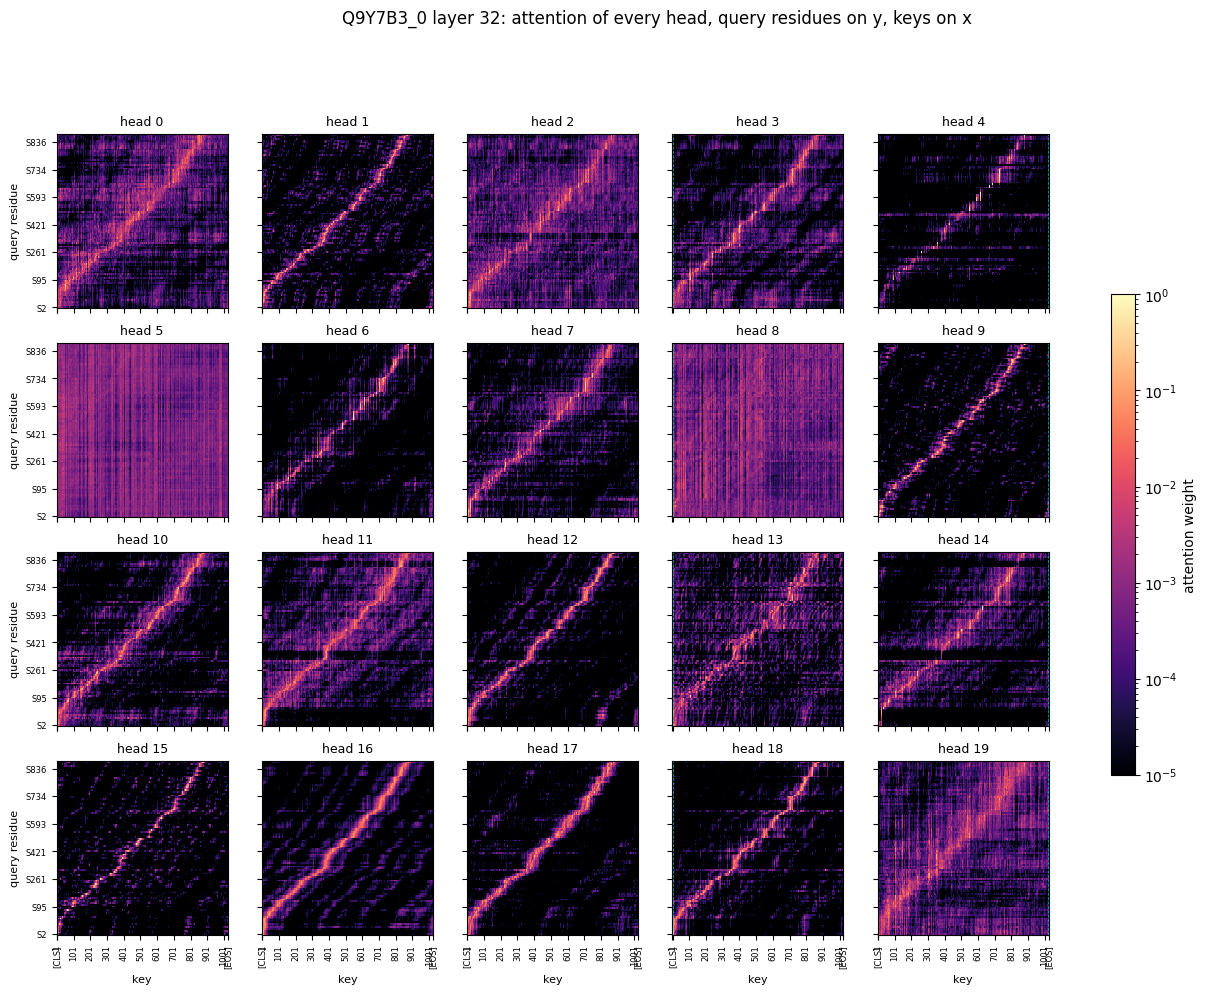

In [17]:
# Per head figures for one layer
plot_attention_maps(att, layer)
plt.show()

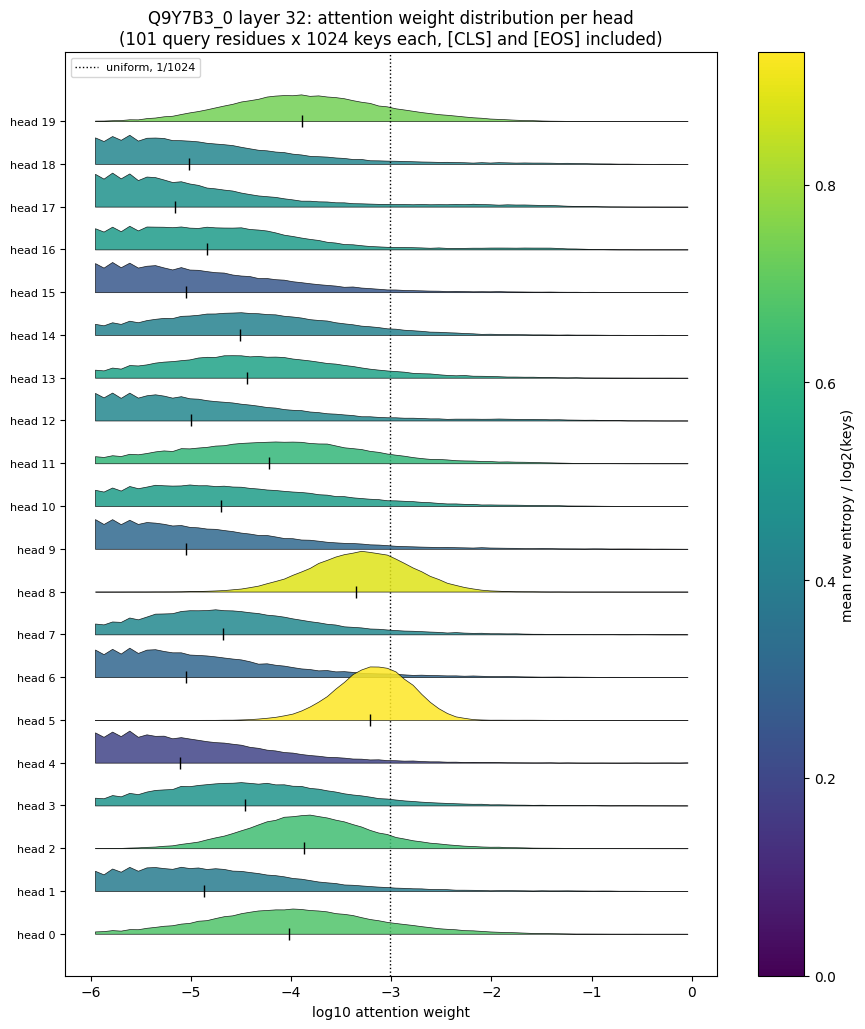

In [18]:
plot_score_distribution(att, layer)
plt.show()

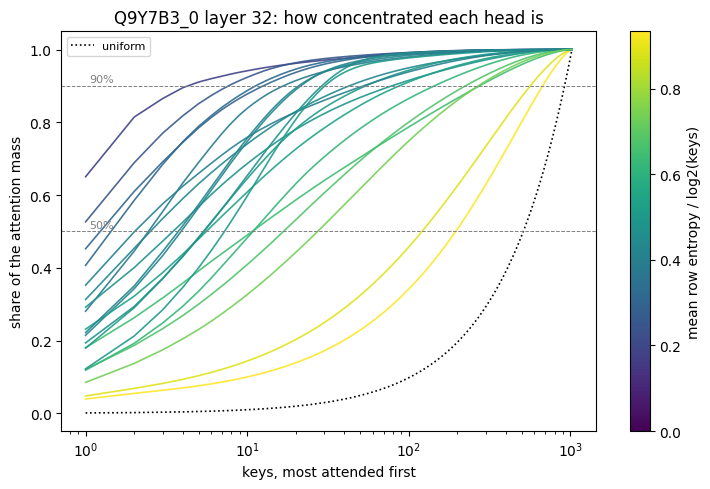

In [19]:
plot_mass_concentration(att, layer)
plt.show()

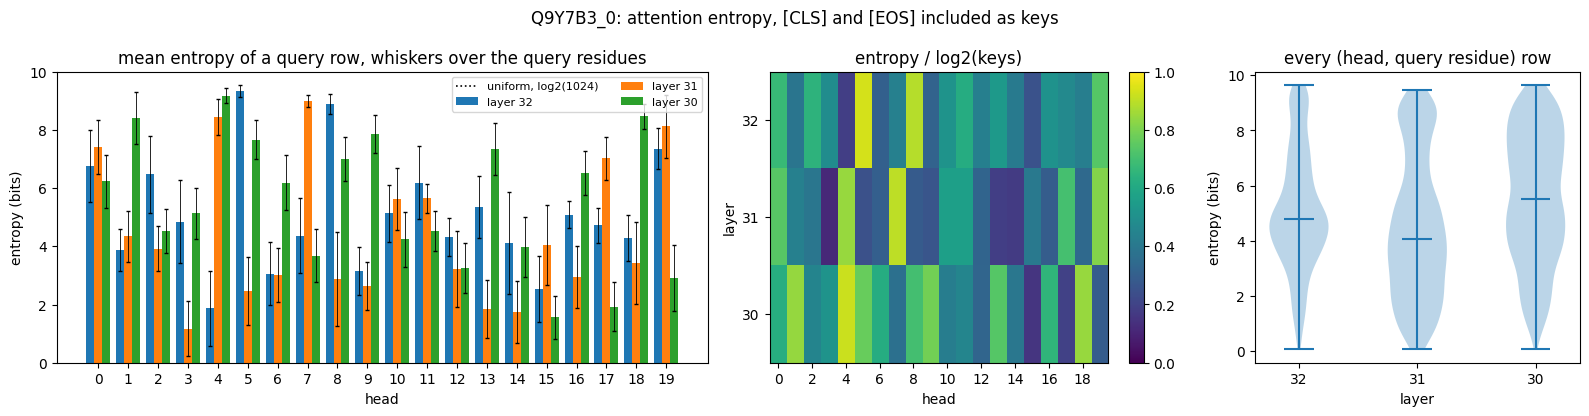

In [20]:
plot_entropy(att, head_table)
plt.show()

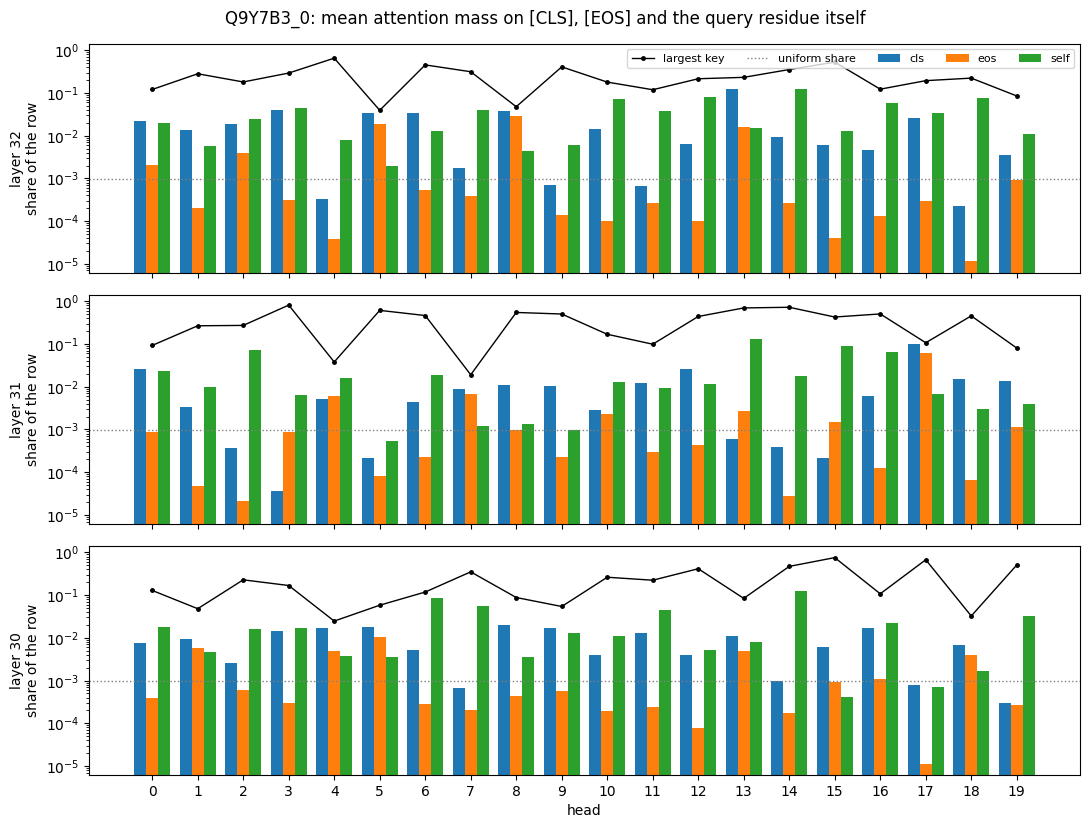

In [21]:
plot_mass_breakdown(att, head_table)
plt.show()

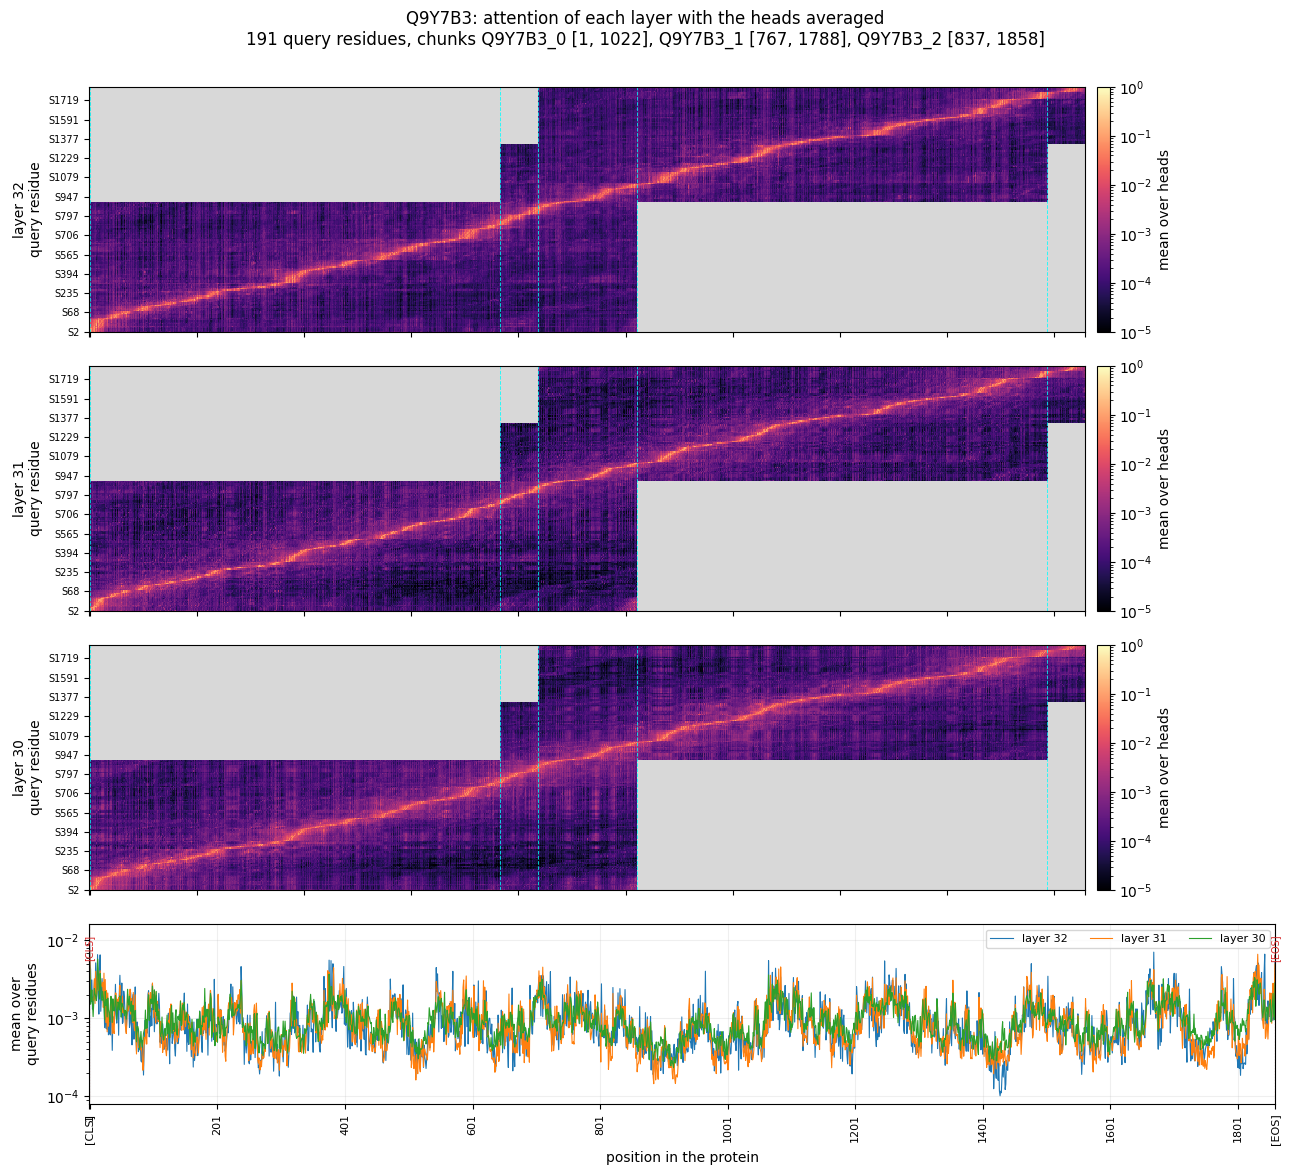

In [22]:
# The heads averaged, over the whole protein rather than one chunk
mixture = protein_mixture(embed)
plot_protein_mixture(mixture)
plt.show()

In [23]:
# Entropy per query residue, for picking single rows apart further
rows = row_entropy_table(att)
rows[rows['layer'] == layer].groupby('head')['entropy_bits'].describe().round(2).head()

,count,mean,std,min,25%,50%,75%,max
head,,,,,,,,
0,101.0,6.75,1.25,2.78,5.74,6.81,7.70,8.87
1,101.0,3.89,0.73,1.78,3.43,3.87,4.43,6.10
2,101.0,6.48,1.32,3.30,5.81,6.73,7.44,8.76
3,101.0,4.84,1.44,1.41,3.85,4.72,5.83,8.55
4,101.0,1.87,1.31,0.08,1.04,1.66,2.45,6.97


### Every protein of the folder

The same per head numbers over all the downloaded proteins, which is what says whether a head is
focused in general or only on this protein. Chunks differ in length, so `norm_entropy` is the
column to average, not `mean_bits`.

In [24]:
folder_table = folder_head_entropy(source_folder)
folder_table.groupby(['layer', 'head'])[['norm_entropy', 'eff_keys', 'keys_90', 'cls_mass', 'eos_mass',
                                         'self_mass', 'top1_mass']].mean().round(4).head(10)

2/67 files
3/67 files


5/67 files
6/67 files


8/67 files
9/67 files
10/67 files
11/67 files
12/67 files
13/67 files
14/67 files
15/67 files


17/67 files
18/67 files
19/67 files
20/67 files
21/67 files
22/67 files
23/67 files
24/67 files
25/67 files


27/67 files
28/67 files
29/67 files
30/67 files
31/67 files


...

48/67 files


51/67 files
52/67 files
53/67 files


55/67 files
56/67 files
57/67 files
58/67 files
59/67 files
60/67 files
61/67 files


63/67 files
64/67 files
65/67 files
66/67 files


norm_entropy    eff_keys   keys_90  cls_mass  eos_mass  self_mass  \
layer head                                                                      
30    0           0.6893   73.411598  117.6154    0.0075    0.0091     0.0253   
      1           0.8220  178.216995  237.2308    0.0249    0.0235     0.0084   
      2           0.5225   25.230301   35.7436    0.0029    0.0150     0.0275   
      3           0.5632   32.418800   41.6795    0.0111    0.0041     0.0206   
      4           0.9077  327.141388  337.5128    0.0403    0.0131     0.0074   
      5           0.7569  120.443802  164.4872    0.0395    0.0288     0.0048   
      6           0.6098   49.852299   82.8462    0.0086    0.0097     0.1192   
      7           0.4004   11.769400   16.1282    0.0013    0.0035     0.0899   
      8           0.7366   96.870300  133.5256    0.0310    0.0180     0.0048   
      9           0.7608  117.446297  154.9872    0.0250    0.0260     0.0198   

            top1_mass  
layer head             
30    0        0.1339  
      1        0.0785  
      2        0.2304  
      3        0.1828  
      4        0.0498  
      5        0.0846  
      6        0.1608  
      7        0.3518  
      8        0.1084  
      9        0.0955

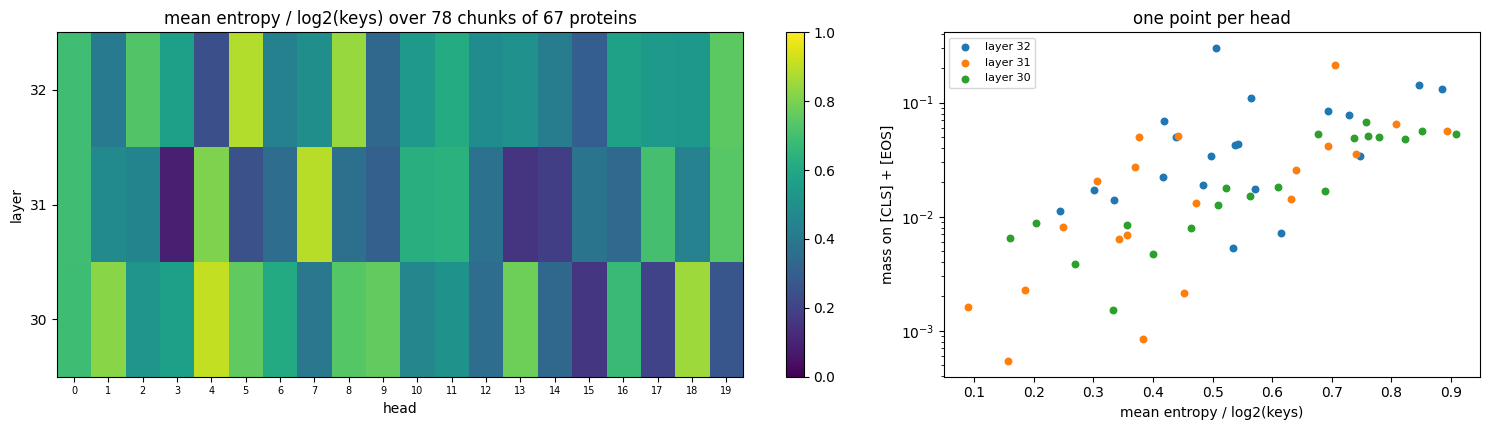

In [25]:
plot_folder_summary(folder_table)
plt.show()

### Entropy on sites against non sites

Two ways of splitting the query residues:

- **by outcome**, the cell of the confusion matrix the run put the residue in, which is the true
  positive against true negative comparison. The attention of this folder was dumped from the
  fold 0 checkpoint, so `folds=[0]` is the honest set of predictions to use: the 9 proteins of
  fold 0's test set that are in the folder, 65 true positives and 325 true negatives. The other
  folds predict 13 more of the proteins, but with models that are not the one being read, and
  `folds=range(5)` takes them in if the coverage is worth more than the mismatch.
- **by label**, a known phosphorylation site against an S that is not one, which needs nothing
  but the info file and so covers all 67 proteins of the folder. Most of those were in fold 0's
  training data though, so it is a different question: how attention differs on sites the model
  has seen, not on ones it was held out from. `proteins=held_out` restricts it to the same 9.

`proteins=` on `folder_query_entropy`, `folder_head_entropy` and `load_outcomes` takes any set of
ids, so a comparison can be run on whatever subset a later question needs.

`head = -1` in the tables below is the mixture, the heads of the layer averaged before the entropy
is taken; `head >= 0` is that head on its own. One consequence of the small protein count: with 9
proteins the Wilcoxon test of `paired_entropy_comparison` bottoms out at p = 0.0039, whatever the
effect, and seven heads sit on that floor here. A single head alone down there would come out of
the Benjamini Hochberg correction over 63 heads at q = 0.25; the seven together pull each other to
q = 0.035. So `paired_q` is only as fine grained as 9 proteins allow, and `same_sign` next to it,
9 of 9 proteins agreeing, is the part that does not depend on a test at all.

In [26]:
from scipy.special import expit
from scipy.stats import false_discovery_control, mannwhitneyu, wilcoxon
from sklearn.metrics import roc_auc_score

MIXTURE = -1

def load_sites(info_path):
    """
    Whole protein, 0 based positions of the known sites of every protein of an info file. Sites are
    1 based in the file, and in chunk coordinates when the file is a chunked one, so the offset of
    the chunk goes back on; a protein split into chunks keeps the union of its chunks' sites.
    """
    info = pd.read_json(info_path).dropna()
    protein = info['parent_id'] if 'parent_id' in info else info['id']
    offsets = info['offset'] if 'offset' in info else pd.Series(0, index=info.index)

    sites = {}
    for name, row_sites, offset in zip(protein, info['sites'], offsets):
        sites.setdefault(name, set()).update(int(site) - 1 + int(offset) for site in row_sites)

    return sites

def load_outcomes(run_folder, folds=range(5), kind='test', threshold=0.5, proteins=None):
    """
    The stitched predictions of a cross validation run as one row per query residue: the label, the
    probability the model gave it, and which cell of the confusion matrix it lands in.

    Test sets are disjoint across the folds, so a protein shows up at most once. "folds" picks which
    models to take the predictions from, a single fold when the attention was dumped from that
    fold's checkpoint, and "proteins" narrows it further to a set of ids. "threshold" is on the
    probability; the tuned one of a fold is in metadata.json under "opt_threshold".
    """
    rows = []
    for fold in folds:
        preds = pd.read_json(f'{run_folder}/fold_{fold}/{kind}_preds_fold_{fold}_stitched.json')
        if proteins is not None:
            preds = preds[preds['id'].isin(set(proteins))]

        for protein, logits, labels, positions in zip(preds['id'], preds['logits'], preds['labels'],
                                                      preds['sequence_indices']):
            probability = expit(np.asarray(logits, dtype=np.float64))
            rows.append(pd.DataFrame({
                'protein' : protein,
                'position' : np.asarray(positions, dtype=int),
                'fold' : fold,
                'label' : np.asarray(labels, dtype=int),
                'probability' : probability,
                'predicted' : (probability >= threshold).astype(int),
            }))

    table = pd.concat(rows, ignore_index=True)
    outcome = np.where(table['label'] == 1,
                       np.where(table['predicted'] == 1, 'TP', 'FN'),
                       np.where(table['predicted'] == 1, 'FP', 'TN'))
    table['outcome'] = outcome
    return table

In [27]:
def mixture_entropy_table(att : ChunkAttention):
    """
    Long form entropies of the mixture, one row per (layer, query residue), shaped like
    row_entropy_table so the two stack. The head column is MIXTURE (-1).
    """
    per_row = entropy(head_mixture(att))
    layers, queries = [axis.ravel() for axis in np.indices(per_row.shape)]

    return pd.DataFrame({
        'protein' : att.protein,
        'chunk_id' : att.chunk_id,
        'layer' : att.layers[layers],
        'head' : MIXTURE,
        'position' : att.queries[queries],
        'residue' : [att.sequence[pos - att.offset] for pos in att.queries[queries]],
        'entropy_bits' : per_row.ravel(),
        'norm_entropy' : per_row.ravel() / uniform_entropy(att.n_keys),
    })

def query_entropy_table(att : ChunkAttention):
    """Per head and mixture entropies of one chunk in one table, the mixture as head = MIXTURE."""
    return pd.concat([row_entropy_table(att), mixture_entropy_table(att)], ignore_index=True)

def folder_query_entropy(folder, proteins=None, limit=None, progress=True):
    """
    query_entropy_table over every chunk of every protein of a folder, stacked. "proteins" reads
    only the files of the given ids, which is the cheap way to run on one fold's test set.
    """
    tables = []
    paths = folder_paths(folder, proteins, limit)
    for i, path in enumerate(paths):
        for att in chunk_attentions(path):
            tables.append(query_entropy_table(att))

        if progress:
            print(f'{i + 1}/{len(paths)} files', end='\r')

    return pd.concat(tables, ignore_index=True)

In [28]:
def attach_groups(table, sites=None, outcomes=None):
    """
    Adds the label and outcome columns to a query entropy table. "site" is filled for every residue
    of a protein the info file knows, "outcome" only for the residues a fold predicted, NaN
    elsewhere, so a comparison on it silently drops the proteins without predictions.
    """
    table = table.copy()
    if sites is not None:
        is_site = [position in sites.get(protein, ()) for protein, position
                   in zip(table['protein'], table['position'])]
        table['site'] = np.where(is_site, 'site', 'non-site')

    if outcomes is not None:
        table = table.merge(outcomes[['protein', 'position', 'fold', 'label', 'probability', 'outcome']],
                            on=['protein', 'position'], how='left')

    return table

def adjust_p_values(p_values):
    """
    Benjamini Hochberg false discovery rate control over a family of tests, scipy's, with the tests
    that were not run (NaN, a head with too few proteins to pair) held out of the family instead of
    counted into its size.
    """
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)
    tested = np.flatnonzero(np.isfinite(p_values))
    adjusted[tested] = false_discovery_control(p_values[tested], method='bh')
    return adjusted

def entropy_comparison(table, group_column, groups, value='entropy_bits'):
    """
    Compares two groups of query residues head by head, the mixture included.

    Besides the two means it reports the AUC of telling the groups apart by entropy alone, which is
    the probability that a residue of the second group has the higher entropy of a random pair: it
    does not care about the scale and handles the very uneven group sizes, 0.5 being no difference
    and above it meaning the second group is the more spread out one. The p value is the Mann
    Whitney U test of the same comparison, of which the AUC is the normalized statistic.
    "diff_bits" is the plain difference of the means, in bits.
    """
    first, second = groups
    records = []
    for (layer, head), rows in table.groupby(['layer', 'head']):
        a = rows.loc[rows[group_column] == first, value].to_numpy()
        b = rows.loc[rows[group_column] == second, value].to_numpy()
        record = {'layer' : layer, 'head' : head, f'n_{first}' : len(a), f'n_{second}' : len(b),
                  f'{first}_bits' : a.mean() if len(a) else np.nan,
                  f'{second}_bits' : b.mean() if len(b) else np.nan}
        record['diff_bits'] = record[f'{second}_bits'] - record[f'{first}_bits']

        if len(a) > 1 and len(b) > 1:
            membership = np.concatenate([np.zeros(len(a)), np.ones(len(b))])
            record['auc'] = roc_auc_score(membership, np.concatenate([a, b]))
            record['p_value'] = mannwhitneyu(b, a, alternative='two-sided').pvalue
        else:
            record['auc'], record['p_value'] = np.nan, np.nan

        records.append(record)

    table = pd.DataFrame.from_records(records)
    # The heads and layers are one family of tests, corrected together
    table['q_value'] = adjust_p_values(table['p_value'])
    return table.sort_values(['layer', 'head'], ignore_index=True)

def paired_entropy_comparison(table, group_column, groups, value='entropy_bits', min_rows=2):
    """
    The same comparison run inside each protein and then across the proteins, which is what the
    pooled one cannot do: the entropy of a row grows with the length of the chunk it sits in (the
    ceiling is log2(keys)), and proteins differ both in length and in how many sites they have, so a
    pooled difference can be a length difference. Here every protein contributes the difference of
    its own two group means, and the Wilcoxon signed rank test asks whether those differences sit on
    one side of zero. "same_sign" counts the proteins that agree with the mean.
    """
    first, second = groups
    records = []
    for (layer, head), rows in table.groupby(['layer', 'head']):
        differences = []
        for _, protein_rows in rows.groupby('protein'):
            a = protein_rows.loc[protein_rows[group_column] == first, value]
            b = protein_rows.loc[protein_rows[group_column] == second, value]
            if len(a) >= min_rows and len(b) >= min_rows:
                differences.append(b.mean() - a.mean())

        differences = np.asarray(differences)
        record = {'layer' : layer, 'head' : head, 'n_proteins' : len(differences),
                  'paired_diff' : differences.mean() if len(differences) else np.nan,
                  'same_sign' : int(max((differences > 0).sum(), (differences < 0).sum())) if len(differences) else 0,
                  'paired_p' : wilcoxon(differences).pvalue if len(differences) > 5 else np.nan}

        records.append(record)

    table = pd.DataFrame.from_records(records)
    table['paired_q'] = adjust_p_values(table['paired_p'])
    return table.sort_values(['layer', 'head'], ignore_index=True)

In [29]:
def plot_mixture_comparison(table, group_column, groups, value='entropy_bits', layers=None, bins=40):
    """
    The mixture entropy of the two groups of query residues, one panel per layer. The vertical lines
    are the group means, the title carries the AUC of the comparison.
    """
    mixture = table[table['head'] == MIXTURE]
    layers = list(dict.fromkeys(mixture['layer'])) if layers is None else layers
    summary = entropy_comparison(mixture, group_column, groups, value=value).set_index(['layer', 'head'])
    fig, axes = plt.subplots(1, len(layers), figsize=(5 * len(layers), 3.8), sharex=True, sharey=True)

    for ax, layer in zip(np.atleast_1d(axes), layers):
        rows = mixture[mixture['layer'] == layer]
        edges = np.histogram_bin_edges(rows[value], bins=bins)
        for i, group in enumerate(groups):
            values = rows.loc[rows[group_column] == group, value]
            ax.hist(values, bins=edges, density=True, alpha=0.55, label=f'{group} (n={len(values)})',
                    color=f'C{i}')
            ax.axvline(values.mean(), color=f'C{i}', lw=1.5, ls='--')

        line = summary.loc[(layer, MIXTURE)]
        ax.set_title(f'layer {layer}: AUC {line["auc"]:.3f}, '
                     f'{line["diff_bits"]:+.3f}\nq = {line["q_value"]:.1e}', fontsize=10)
        ax.set_xlabel(f'mixture {value.replace("_", " ")}')
        ax.legend(fontsize=8)

    np.atleast_1d(axes)[0].set_ylabel('density')
    fig.suptitle(f'Entropy of the head mixture, {groups[0]} against {groups[1]}', y=1.02)
    fig.tight_layout()
    return fig

def plot_head_comparison(summary, groups, n_cols=1):
    """
    Per head means of the two groups with the mixture alongside, one panel per layer. The heads are
    ordered as they are stored; the rightmost pair, past the dashed line, is the mixture.
    """
    first, second = groups
    layers = list(dict.fromkeys(summary['layer']))
    fig, axes = plt.subplots(len(layers), n_cols, figsize=(12, 2.9 * len(layers)), sharex=True, sharey=True)

    for ax, layer in zip(np.atleast_1d(axes), layers):
        rows = summary[summary['layer'] == layer].sort_values('head')
        heads = rows['head'].to_numpy()
        # MIXTURE (-1) is sorted first, move it to the end and set it apart
        order = np.argsort(np.where(heads == MIXTURE, heads.max() + 1, heads))
        rows, positions = rows.iloc[order], np.arange(len(heads))
        for i, group in enumerate(groups):
            ax.bar(positions + (i - 0.5) * 0.4, rows[f'{group}_bits'], width=0.4, color=f'C{i}',
                   label=group)

        significant = rows['q_value'] < 0.05
        ax.plot(positions[significant.to_numpy()], np.full(significant.sum(), ax.get_ylim()[1] * 0.97),
                marker='*', ls='', color='black', ms=6, label='q < 0.05')
        ax.axvline(len(heads) - 1.5, color='grey', lw=1, ls='--')
        ax.set_xticks(positions)
        ax.set_xticklabels([('mix' if head == MIXTURE else str(head)) for head in rows['head']], fontsize=8)
        ax.set_ylabel(f'layer {layer}\nentropy (bits)')

    np.atleast_1d(axes)[0].legend(fontsize=8, ncol=3)
    np.atleast_1d(axes)[-1].set_xlabel('head')
    fig.suptitle(f'Mean entropy per head, {first} against {second}', y=1.0)
    fig.tight_layout()
    return fig

def plot_effect_sizes(summary, groups, cmap='coolwarm', flag_column='q_value'):
    """
    The AUC of every head and of the mixture as a layer by head grid: how well the entropy of that
    head alone separates the two groups of residues. 0.5 is no difference, red means the second
    group attends more widely, blue that it attends more narrowly. The dots mark q < 0.05.
    """
    grid = summary.pivot(index='layer', columns='head', values='auc')
    grid = grid[[column for column in grid.columns if column != MIXTURE] + [MIXTURE]]
    flags = summary.pivot(index='layer', columns='head', values=flag_column).reindex(columns=grid.columns)
    extent = np.nanmax(np.abs(grid.to_numpy() - 0.5))

    fig, ax = plt.subplots(figsize=(0.5 * len(grid.columns) + 3, 0.6 * len(grid.index) + 2.4))
    image = ax.imshow(grid.to_numpy(), aspect='auto', cmap=cmap, vmin=0.5 - extent, vmax=0.5 + extent)
    rows, columns = np.where(flags.to_numpy() < 0.05)
    ax.plot(columns, rows, marker='.', ls='', color='black', ms=5)

    ax.set_xticks(range(len(grid.columns)),
                  [('mix' if head == MIXTURE else str(head)) for head in grid.columns], fontsize=8)
    ax.set_yticks(range(len(grid.index)), [str(layer) for layer in grid.index])
    ax.axvline(len(grid.columns) - 1.5, color='black', lw=1, ls='--')
    ax.set_xlabel('head')
    ax.set_ylabel('layer')
    ax.set_title(f'P(entropy of a {groups[1]} residue > entropy of a {groups[0]} residue)\n'
                 f'dots mark {flag_column} < 0.05')
    fig.colorbar(image, ax=ax, label='AUC')
    fig.tight_layout()
    return fig

In [30]:
run_folder = '../model/logs/finetuning_drop_S_2_650M_dbptm_chunked_max'
fold = 0          # The checkpoint the attention of this folder was dumped from

sites = load_sites('../data/dbptm/dbptm_info.json')
outcomes = load_outcomes(run_folder, folds=[fold], proteins=folder_proteins(source_folder))
held_out = sorted(outcomes['protein'].unique())

# Which proteins to compute the entropies over: None reads the whole folder, held_out only the
# proteins that fold did not train on, and any other set of ids works the same way
proteins = None
query_entropy = attach_groups(folder_query_entropy(source_folder, proteins=proteins),
                              sites=sites, outcomes=outcomes)

print(f'\n{len(query_entropy)} (layer, head, residue) entropies over '
      f'{query_entropy["protein"].nunique()} proteins')
print(f'fold {fold} held out {len(held_out)} of them: {", ".join(held_out)}\n')
print(query_entropy[query_entropy['head'] == MIXTURE]
      .groupby('site')['protein'].agg(['size', 'nunique']).rename(columns={'size' : 'rows'}))
print(query_entropy[query_entropy['head'] == MIXTURE]
      .dropna(subset=['outcome']).groupby('outcome')['protein'].agg(['size', 'nunique']))

1/67 files


3/67 files


5/67 files
6/67 files


8/67 files
9/67 files
10/67 files
11/67 files
12/67 files
13/67 files
14/67 files
15/67 files


17/67 files
18/67 files
19/67 files
20/67 files
21/67 files
22/67 files
23/67 files
24/67 files
25/67 files
26/67 files
27/67 files


...

46/67 files
47/67 files
48/67 files


50/67 files


52/67 files
53/67 files
54/67 files
55/67 files
56/67 files
57/67 files
58/67 files
59/67 files


61/67 files
62/67 files
63/67 files
64/67 files
65/67 files
66/67 files



226170 (layer, head, residue) entropies over 67 proteins
fold 0 held out 9 of them: Q9Y7K9, Q9Y7N1, Q9Y7N9, Q9Y7R3, Q9Y7R5, Q9Y7S8, Q9Y7U5, Q9Y7V1, Q9Y7Z4

          rows  nunique
site                   
non-site  9297       67
site      1473       65
         size  nunique
outcome               
FN         48        6
FP        189        9
TN        975        9
TP        195        9


In [31]:
# True positives against true negatives, on the proteins a fold predicted
outcome_rows = query_entropy.dropna(subset=['outcome'])
outcome_summary = entropy_comparison(outcome_rows, 'outcome', ('TN', 'TP')).merge(
    paired_entropy_comparison(outcome_rows, 'outcome', ('TN', 'TP')), on=['layer', 'head'])

outcome_summary[outcome_summary['head'] == MIXTURE].round(4)

,layer,head,n_TN,n_TP,TN_bits,TP_bits,diff_bits,auc,p_value,q_value,n_proteins,paired_diff,same_sign,paired_p,paired_q
0,30,-1,325,65,6.9683,6.9086,-0.0597,0.4898,0.7946,0.8074,9,0.1267,8,0.0117,0.0434
21,31,-1,325,65,6.1316,6.1166,-0.0150,0.4785,0.5851,0.6582,9,0.1510,8,0.0117,0.0434
42,32,-1,325,65,6.5446,6.2705,-0.2741,0.3578,0.0003,0.0009,9,-0.1311,6,0.2500,0.3663


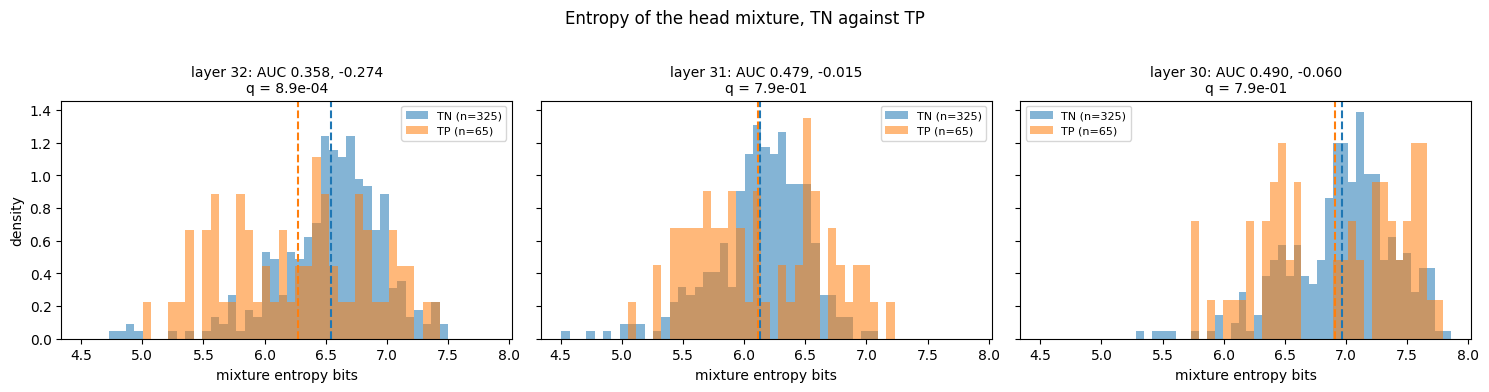

In [32]:
plot_mixture_comparison(query_entropy.dropna(subset=['outcome']), 'outcome', ('TN', 'TP'))
plt.show()

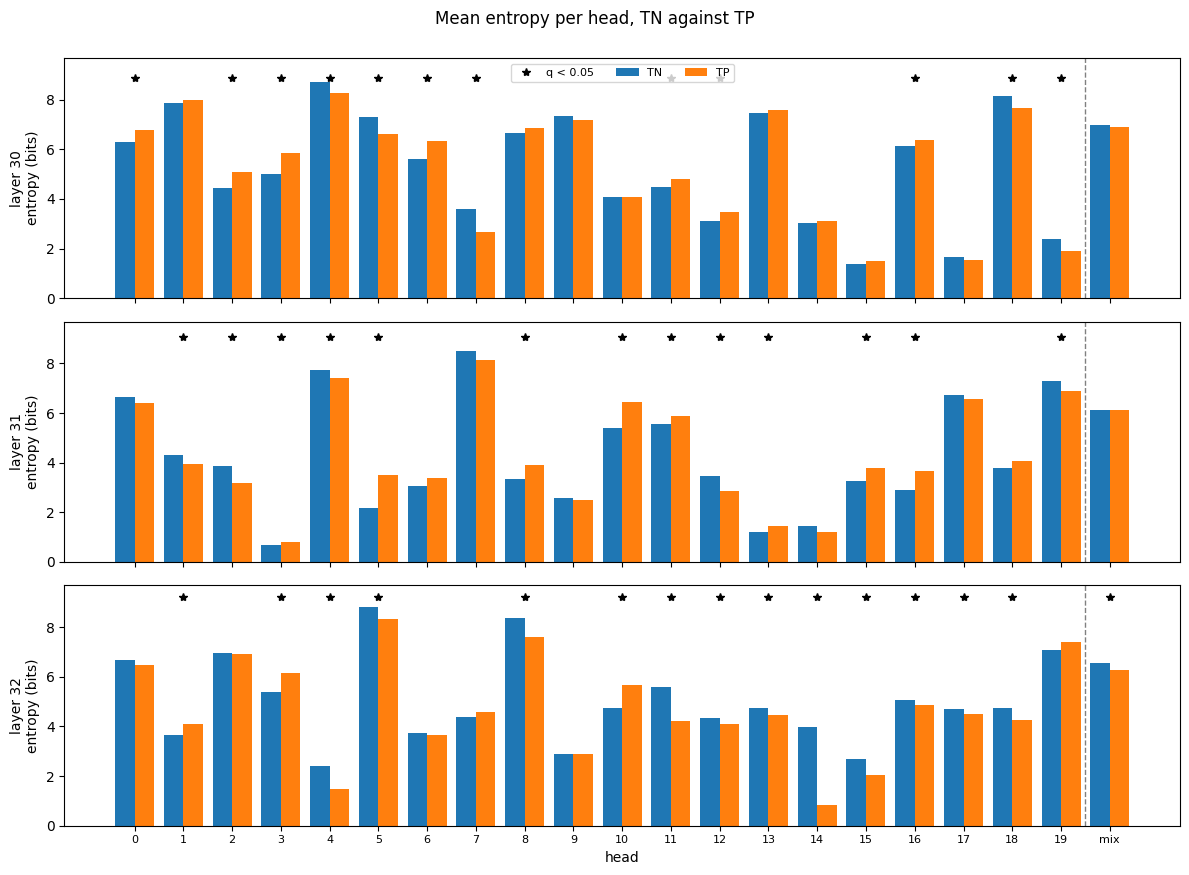

In [33]:
plot_head_comparison(outcome_summary, ('TN', 'TP'))
plt.show()

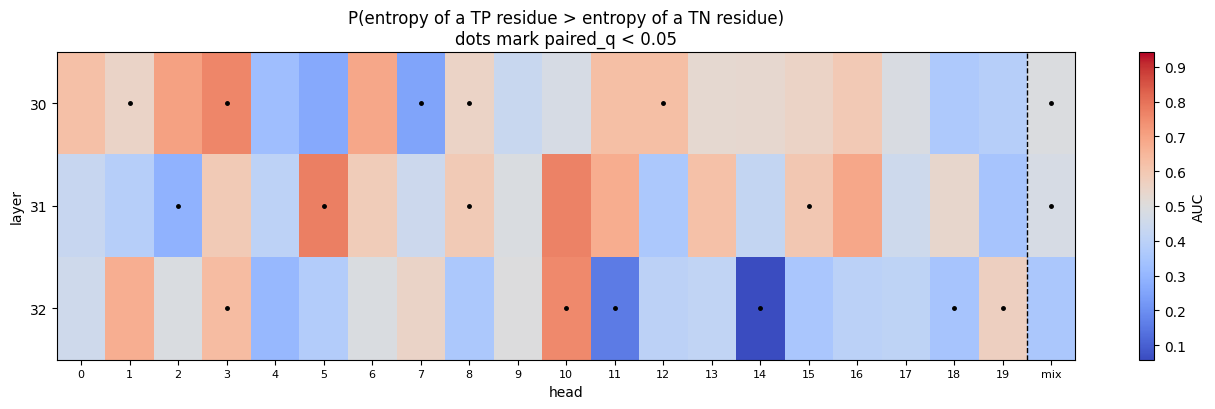

In [34]:
plot_effect_sizes(outcome_summary, ('TN', 'TP'), flag_column='paired_q')
plt.show()

In [35]:
# The heads whose entropy separates the two best, pooled and within protein side by side
columns = ['layer', 'head', 'n_TN', 'n_TP', 'TN_bits', 'TP_bits', 'auc', 'q_value',
           'n_proteins', 'paired_diff', 'same_sign', 'paired_q']
outcome_summary.reindex(outcome_summary['auc'].sub(0.5).abs().sort_values(ascending=False).index)[columns].head(10).round(4)

,layer,head,n_TN,n_TP,TN_bits,TP_bits,auc,q_value,n_proteins,paired_diff,same_sign,paired_q
57,32,14,325,65,3.9895,0.8248,0.0581,0.0,9,-3.0508,9,0.0352
54,32,11,325,65,5.5842,4.2155,0.1563,0.0,9,-1.3734,8,0.0434
27,31,5,325,65,2.1775,3.4880,0.7745,0.0,9,1.2363,8,0.0434
32,31,10,325,65,5.3877,6.4559,0.7660,0.0,9,0.8321,8,0.0984
4,30,3,325,65,4.9991,5.8459,0.7611,0.0,9,0.7971,8,0.0434
53,32,10,325,65,4.7276,5.6755,0.7521,0.0,9,0.8609,9,0.0352
8,30,7,325,65,3.5765,2.6657,0.2503,0.0,9,-0.7110,9,0.0352
6,30,5,325,65,7.2890,6.6363,0.2626,0.0,9,-0.2551,7,0.1230
24,31,2,325,65,3.8590,3.1746,0.2888,0.0,9,-0.7542,9,0.0352
3,30,2,325,65,4.4425,5.0787,0.7023,0.0,9,0.5738,7,0.0586


In [36]:
# The same split by label instead, which covers every protein of the folder rather than the 9 the
# fold held out, and normalized entropy so chunks of different length are on one scale.
# query_entropy[query_entropy['protein'].isin(held_out)] runs it on the held out ones only.
site_summary = entropy_comparison(query_entropy, 'site', ('non-site', 'site'), value='norm_entropy').merge(
    paired_entropy_comparison(query_entropy, 'site', ('non-site', 'site'), value='norm_entropy'),
    on=['layer', 'head'])

site_summary[site_summary['head'] == MIXTURE].round(4)

,layer,head,n_non-site,n_site,non-site_bits,site_bits,diff_bits,auc,p_value,q_value,n_proteins,paired_diff,same_sign,paired_p,paired_q
0,30,-1,3099,491,0.7438,0.7670,0.0232,0.6690,0.0000,0.0000,50,0.0071,31,0.0037,0.0072
21,31,-1,3099,491,0.6597,0.6762,0.0166,0.6311,0.0000,0.0000,50,0.0075,36,0.0049,0.0094
42,32,-1,3099,491,0.6983,0.7015,0.0032,0.5295,0.0352,0.0452,50,-0.0109,32,0.0149,0.0247


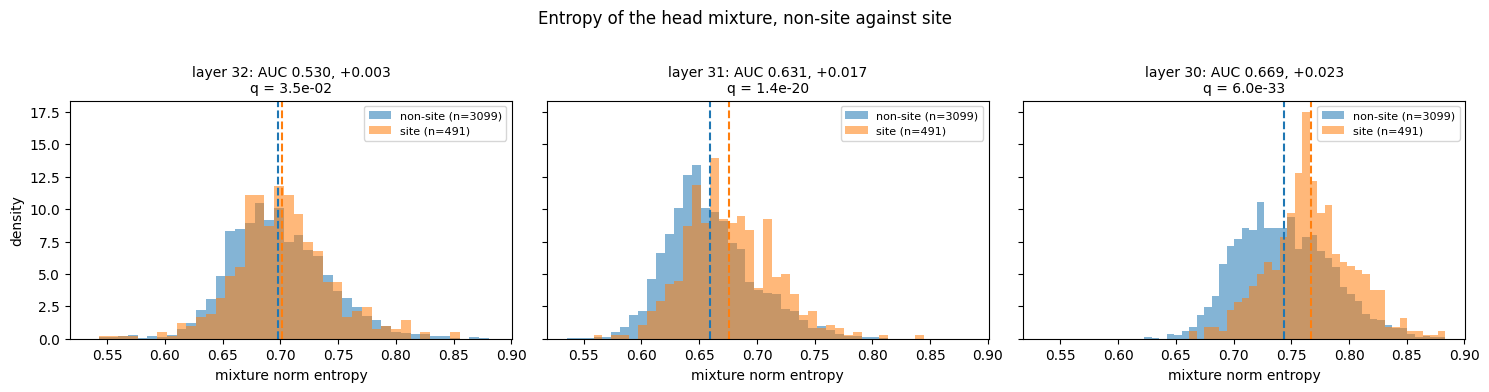

In [37]:
plot_mixture_comparison(query_entropy, 'site', ('non-site', 'site'), value='norm_entropy')
plt.show()

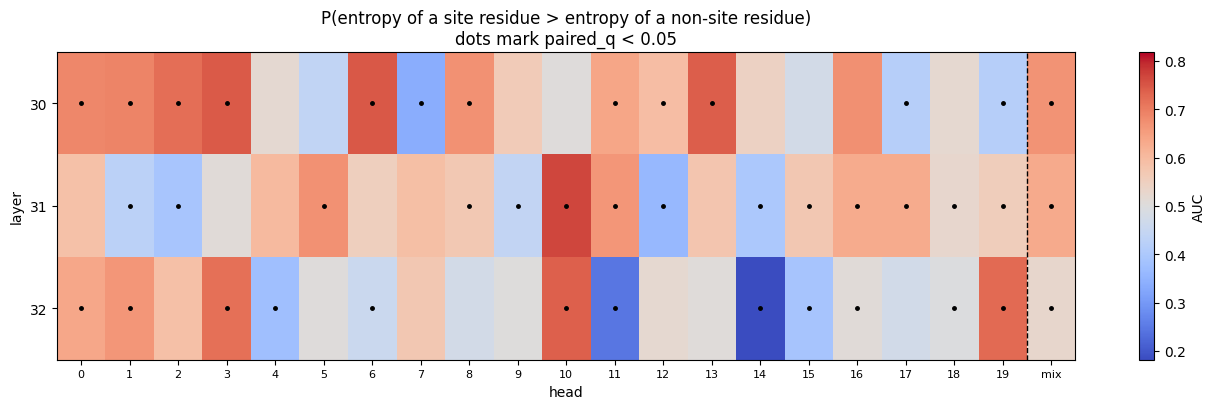

In [38]:
plot_effect_sizes(site_summary, ('non-site', 'site'), flag_column='paired_q')
plt.show()